In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler

In [2]:
data=load_wine()
X=data.data
y=data.target
X

array([[1.423e+01, 1.710e+00, 2.430e+00, ..., 1.040e+00, 3.920e+00,
        1.065e+03],
       [1.320e+01, 1.780e+00, 2.140e+00, ..., 1.050e+00, 3.400e+00,
        1.050e+03],
       [1.316e+01, 2.360e+00, 2.670e+00, ..., 1.030e+00, 3.170e+00,
        1.185e+03],
       ...,
       [1.327e+01, 4.280e+00, 2.260e+00, ..., 5.900e-01, 1.560e+00,
        8.350e+02],
       [1.317e+01, 2.590e+00, 2.370e+00, ..., 6.000e-01, 1.620e+00,
        8.400e+02],
       [1.413e+01, 4.100e+00, 2.740e+00, ..., 6.100e-01, 1.600e+00,
        5.600e+02]])

In [3]:
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)
X_scaled

array([[ 1.51861254, -0.5622498 ,  0.23205254, ...,  0.36217728,
         1.84791957,  1.01300893],
       [ 0.24628963, -0.49941338, -0.82799632, ...,  0.40605066,
         1.1134493 ,  0.96524152],
       [ 0.19687903,  0.02123125,  1.10933436, ...,  0.31830389,
         0.78858745,  1.39514818],
       ...,
       [ 0.33275817,  1.74474449, -0.38935541, ..., -1.61212515,
        -1.48544548,  0.28057537],
       [ 0.20923168,  0.22769377,  0.01273209, ..., -1.56825176,
        -1.40069891,  0.29649784],
       [ 1.39508604,  1.58316512,  1.36520822, ..., -1.52437837,
        -1.42894777, -0.59516041]])

In [4]:
pca=PCA(n_components=2)
X_reduced=pca.fit_transform(X_scaled)

print("Original Shape:",X.shape)
print("Reduced Shape:",X_reduced.shape)

Original Shape: (178, 13)
Reduced Shape: (178, 2)


In [5]:
explained_variance=pca.explained_variance_ratio_
print(f"Explained Variance Ratio:",explained_variance)

Explained Variance Ratio: [0.36198848 0.1920749 ]


In [6]:
variance_retained=np.sum(explained_variance)
print(f"Total Variance Retained: {variance_retained}")

Total Variance Retained: 0.5540633835693527


In [7]:
information_loss=1-variance_retained
print(f"Info loss: {information_loss}")

Info loss: 0.4459366164306473


In [8]:
variance_retained+information_loss

1.0

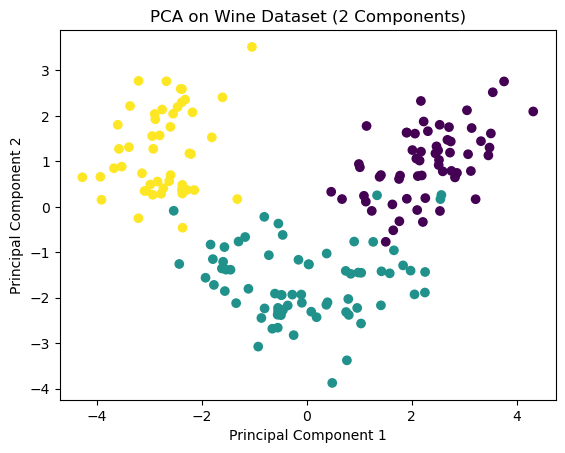

In [9]:
plt.figure()
plt.scatter(X_reduced[:,0],X_reduced[:,1],c=y)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA on Wine Dataset (2 Components)")
plt.savefig("PCA on Wine Dataset (2 Components).png",dpi=100)
plt.show()